# Two-Dimensional Lattice Geometry

This notebook constructs a triangular direct lattice, its Wigner--Seitz cell, reciprocal lattice, first Brillouin zone, and a high-symmetry wavevector path.

```mermaid
flowchart TD
    D["DirectLattice2D"] --> W["WignerSeitzCell2D"]
    D --> R["ReciprocalLattice2D"]
    R --> B["FirstBrillouinZone2D"]
    B --> K["KPointPath2D"]
```

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from physkit.periodic import (
    DirectLattice,
    ReciprocalLattice,
    DirectLattice2D,
    FirstBrillouinZone2D,
    KPointPath2D,
    ReciprocalLattice2D,
    WignerSeitzCell2D,
)

## Direct lattice

The triangular lattice is generated by

$$\mathbf a_1=a(1,0),\qquad\mathbf a_2=a(1/2,\sqrt{3}/2).$$

The primitive-basis matrix stores these vectors as columns.

In [2]:
a = 1.0
a1 = np.array([a, 0.0])
a2 = np.array([0.5 * a, 0.5 * np.sqrt(3.0) * a])

direct_lattice = DirectLattice2D(a1=a1, a2=a2)
assert isinstance(direct_lattice, DirectLattice)
print("Primitive basis A:")
print(direct_lattice.A)
print("Primitive-cell area:", direct_lattice.measure)

Primitive basis A:
[[1.        0.5      ]
 [0.        0.8660254]]
Primitive-cell area: 0.8660254037844386


In [3]:
shell = 3
direct_modes = np.array([
    (m1, m2)
    for m1 in range(-shell, shell + 1)
    for m2 in range(-shell, shell + 1)
], dtype=np.int64)
direct_points = direct_lattice.vector(direct_modes)

## Wigner-Seitz cell

Each nonzero lattice vector $\mathbf R$ defines the half-plane

$$
\mathbf{R} \cdot \mathbf{x}
  \leq \frac{|\mathbf R|^2}{2}
$$

The intersection of these half-planes is the Wigner-Seitz polygon.

In [ ]:
wigner_seitz_cell = WignerSeitzCell2D(
    lattice=direct_lattice,
    neighbor_shell=2,
)

print("Wigner-Seitz vertices:")
print(wigner_seitz_cell.vertices)
print("Wigner-Seitz area:", wigner_seitz_cell.measure)

assert np.isclose(wigner_seitz_cell.measure, direct_lattice.measure)

Wigner–Seitz vertices:
[[-0.5        -0.28867513]
 [ 0.         -0.57735027]
 [ 0.5        -0.28867513]
 [ 0.5         0.28867513]
 [ 0.          0.57735027]
 [-0.5         0.28867513]]
Wigner–Seitz area: 0.8660254037844384


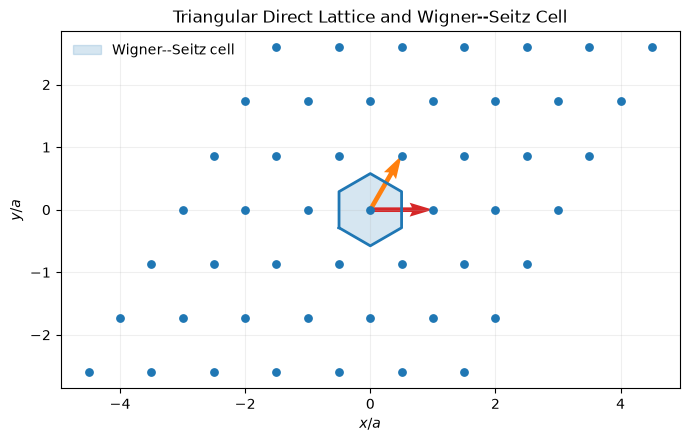

In [5]:
closed_ws = np.vstack((
    wigner_seitz_cell.vertices,
    wigner_seitz_cell.vertices[0],
))

fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(direct_points[:, 0], direct_points[:, 1], s=28, color="tab:blue", zorder=3)
ax.fill(closed_ws[:, 0], closed_ws[:, 1], color="tab:blue", alpha=0.18, label="Wigner--Seitz cell")
ax.plot(closed_ws[:, 0], closed_ws[:, 1], color="tab:blue", linewidth=2.0)
ax.quiver([0.0, 0.0], [0.0, 0.0], [a1[0], a2[0]], [a1[1], a2[1]], angles="xy", scale_units="xy", scale=1.0, color=["tab:red", "tab:orange"])
ax.set_aspect("equal")
ax.set_xlabel(r"$x/a$")
ax.set_ylabel(r"$y/a$")
ax.set_title("Triangular Direct Lattice and Wigner--Seitz Cell")
ax.legend(frameon=False)
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

## Reciprocal Lattice

Let the two-dimensional direct-lattice primitive-basis matrix be

$$
A
=
\begin{bmatrix}
\mathbf a_1
&
\mathbf a_2
\end{bmatrix},
$$

where $\mathbf a_1$ and $\mathbf a_2$ are the direct primitive vectors.

The reciprocal-lattice primitive-basis matrix is

$$
\boxed{
B
=
2\pi A^{-\mathsf T}
},
$$

where

$$
B
=
\begin{bmatrix}
\mathbf b_1
&
\mathbf b_2
\end{bmatrix}.
$$

For a two-dimensional lattice embedded in the $xy$-plane, define the oriented primitive-basis area as

$$
\Omega
=
\left(
\mathbf a_1
\times
\mathbf a_2
\right)
\cdot
\hat{\mathbf z}.
$$

The reciprocal primitive vectors are

$$
\begin{aligned}
\mathbf b_1
&=
2\pi
\frac{
\mathbf a_2\times\hat{\mathbf z}
}{
\Omega
},
\\[4pt]
\mathbf b_2
&=
2\pi
\frac{
\hat{\mathbf z}\times\mathbf a_1
}{
\Omega
}.
\end{aligned}
$$

If

$$
\mathbf a_1
=
\begin{bmatrix}
a_{1x}\\
a_{1y}
\end{bmatrix},
\qquad
\mathbf a_2
=
\begin{bmatrix}
a_{2x}\\
a_{2y}
\end{bmatrix},
$$

then

$$
\Omega
=
a_{1x}a_{2y}
-
a_{1y}a_{2x},
$$

and

$$
\begin{aligned}
\mathbf b_1
&=
\frac{2\pi}{\Omega}
\begin{bmatrix}
a_{2y}\\
-a_{2x}
\end{bmatrix},
\\[6pt]
\mathbf b_2
&=
\frac{2\pi}{\Omega}
\begin{bmatrix}
-a_{1y}\\
a_{1x}
\end{bmatrix}.
\end{aligned}
$$

The direct and reciprocal primitive vectors satisfy

$$
\boxed{
\mathbf a_\mu\cdot\mathbf b_\nu
=
2\pi\delta_{\mu\nu}
},
$$

or, in matrix form,

$$
\boxed{
A^{\mathsf T}B
=
2\pi I
}.
$$

Every reciprocal-lattice vector is an integer linear combination of the reciprocal primitive vectors:

$$
\mathbf G_{\mathbf m}
=
B\mathbf m
=
m_1\mathbf b_1
+
m_2\mathbf b_2,
\qquad
\mathbf m
=
\begin{bmatrix}
m_1\\
m_2
\end{bmatrix}
\in\mathbb Z^2.
$$

In [6]:
# ------------------------------------------------------------
# Direct primitive basis
# ------------------------------------------------------------
print("direct_lattice.a1:{}".format(direct_lattice.a1))
print("direct_lattice.a1:{}".format(direct_lattice.a2))
print("direct_lattice.A:")
print(direct_lattice.primitive_basis)


# ------------------------------------------------------------
# Oriented primitive-basis area
# ------------------------------------------------------------

Omega = (
    a1[0] * a2[1]
    - a1[1] * a2[0]
)


print("\nOriented primitive-basis area Omega:")
print(Omega)


# ------------------------------------------------------------
# Explicit reciprocal primitive vectors
# ------------------------------------------------------------

b1_explicit = (
    2.0
    * np.pi
    / Omega
    * np.array(
        [
            a2[1],
            -a2[0],
        ],
        dtype=np.float64,
    )
)

b2_explicit = (
    2.0
    * np.pi
    / Omega
    * np.array(
        [
            -a1[1],
            a1[0],
        ],
        dtype=np.float64,
    )
)


print("\nExplicit reciprocal primitive vector b1:")
print(b1_explicit)

print("\nExplicit reciprocal primitive vector b2:")
print(b2_explicit)


# ------------------------------------------------------------
# Construct the reciprocal lattice
# ------------------------------------------------------------

reciprocal_lattice = (
    ReciprocalLattice2D.from_direct_lattice(
        direct_lattice=direct_lattice,
    )
)

b1 = reciprocal_lattice.b1
b2 = reciprocal_lattice.b2
B = reciprocal_lattice.primitive_basis


print("\nReciprocal primitive vector b1:")
print(b1)

print("\nReciprocal primitive vector b2:")
print(b2)

print("\nReciprocal primitive basis B:")
print(B)


# ------------------------------------------------------------
# Validate the explicit reciprocal vectors
# ------------------------------------------------------------

assert np.allclose(
    b1,
    b1_explicit,
)

assert np.allclose(
    b2,
    b2_explicit,
)


# ------------------------------------------------------------
# Validate direct-reciprocal duality
# ------------------------------------------------------------

direct_reciprocal_products = (
    A.T @ B
)

expected_products = (
    2.0
    * np.pi
    * np.eye(2)
)


print("\nA^T B:")
print(direct_reciprocal_products)

print("\n2 pi I:")
print(expected_products)


assert np.allclose(
    direct_reciprocal_products,
    expected_products,
)


# ------------------------------------------------------------
# Construct reciprocal-lattice vectors
# ------------------------------------------------------------

# Reciprocal modes are the integer coefficients m_1, m_2 used
# to generate the reciprocal vectors
m1_lower = -1
m1_upper = 1
m2_lower = -1
m2_upper = 1
m1_indices = np.arange(start=-m1_lower, stop = m1_upper+1, dtype=np.int64)
m2_indices = np.arange(start=-m2_lower, stop = m2_upper+1, dtype=np.int64)
m1_grid, m2_grid = np.meshgrid(m1_indices, m2_indices, indexing="ij")
reciprocal_indices = np.column_stack(
    (
        m1_grid.ravel(),
        m2_grid.ravel()
    )
)

print("\nReciprocal-lattice indices:")
print(reciprocal_indices)

print("\nReciprocal-lattice vectors G_m:")
reciprocal_vectors = reciprocal_lattice.vector(
    indices=reciprocal_indices
)

print(reciprocal_vectors)


# Verify G_m = m1 b1 + m2 b2
reciprocal_vectors_explicit = (
    reciprocal_indices[:, 0, None] * b1
    + reciprocal_indices[:, 1, None] * b2
)

assert np.allclose(
    reciprocal_vectors,
    reciprocal_vectors_explicit,
)

direct_lattice.a1:[1. 0.]
direct_lattice.a1:[0.5       0.8660254]
direct_lattice.A:


AttributeError: 'DirectLattice2D' object has no attribute 'primitive_basis'

## 4. First Brillouin zone

The first Brillouin zone is the Wigner-Seitz cell of the reciprocal lattice. Its area must satisfy

$$
\Omega_{\mathrm{BZ}}
  = \frac{(2\pi)^2}{\Omega}
$$

In [ ]:
first_brillouin_zone = FirstBrillouinZone2D(
    reciprocal_lattice=reciprocal_lattice,
    neighbor_shell=2,
)

expected_zone_area = (
    (2.0 * np.pi) ** 2
    / direct_lattice.primitive_cell_measure
)

print("First-Brillouin-zone vertices:")
print(first_brillouin_zone.vertices)
print("Calculated zone area:", first_brillouin_zone.measure)
print("Expected zone area:", expected_zone_area)

assert np.isclose(first_brillouin_zone.measure, expected_zone_area)

## 5. High-symmetry path $\Gamma\to M\to K\to\Gamma$

For the hexagonal Brillouin zone, $K$ is a vertex and $M$ is the midpoint of an adjacent edge. The path object interpolates these geometric nodes and records cumulative distance.

In [ ]:
zone_vertices = first_brillouin_zone.vertices
rightmost_index = np.argmax(zone_vertices[:, 0])
K = zone_vertices[rightmost_index]
K_next = zone_vertices[(rightmost_index + 1) % len(zone_vertices)]
M = 0.5 * (K + K_next)
Gamma = np.zeros(2)

k_path = KPointPath2D(
    nodes=np.array([Gamma, M, K, Gamma]),
    labels=(r"$\Gamma$", r"$M$", r"$K$", r"$\Gamma$"),
    points_per_segment=51,
)

print("Number of path points:", k_path.size)
print("Node distances:", k_path.node_distances)

In [ ]:
reciprocal_points = reciprocal_lattice.vector(direct_modes)
closed_bz = np.vstack((zone_vertices, zone_vertices[0]))

fig, ax = plt.subplots(figsize=(8, 8))

# plot lattice points
ax.scatter(
    reciprocal_points[:, 0], 
    reciprocal_points[:, 1], 
    s=22, 
    color="tab:green", 
    alpha=0.55)

# plot and fill the FBZ
ax.fill(
    closed_bz[:, 0], 
    closed_bz[:, 1], 
    color="tab:purple", 
    alpha=0.16, 
    label="First Brillouin zone")
ax.plot(closed_bz[:, 0], closed_bz[:, 1], color="tab:purple", linewidth=2.0)


# plot the k-path
ax.plot(
    k_path.values[:, 0], 
    k_path.values[:, 1], 
    color="black", 
    linewidth=2.0, 
    label=r"$\Gamma-M-K-\Gamma$")
# plot high symmetry points
ax.scatter(
    k_path.nodes[:, 0], 
    k_path.nodes[:, 1], 
    s=70, 
    color="tab:red", 
    zorder=4)
# label high symmetry points
for point, label in zip(k_path.nodes, k_path.labels):
    ax.annotate(
        label, 
        point, 
        xytext=(6, 6), 
        textcoords="offset points")

ax.set_aspect("equal")
ax.set_xlabel(r"$k_x$")
ax.set_ylabel(r"$k_y$")
ax.set_title("Reciprocal Lattice, First Brillouin Zone, and $k$-Path")
ax.legend(frameon=False)
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

## Summary

The direct-lattice primitive basis determines the reciprocal basis. The Wigner--Seitz construction applied to the direct lattice produces the primitive cell, while the same construction applied to the reciprocal lattice produces the first Brillouin zone. A $k$-path is then an ordered sampling through that zone.